Dataset Shape: (1000, 10)

First 5 Rows:


,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,27-03-2016 00:53,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,04-04-2016 01:39,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,13-03-2016 20:35,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,10-01-2016 02:31,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,03-06-2016 03:36,0



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 78.3+ KB

Missing Values:
Daily Time Spent on Site    0
Age                         0
Area Income                 0
Daily Internet Usage        0
Ad Topic Lin

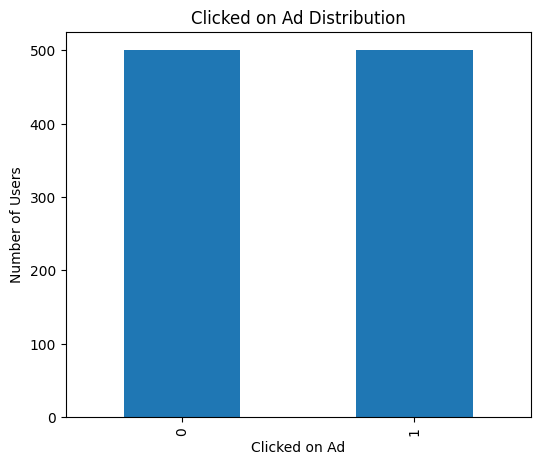

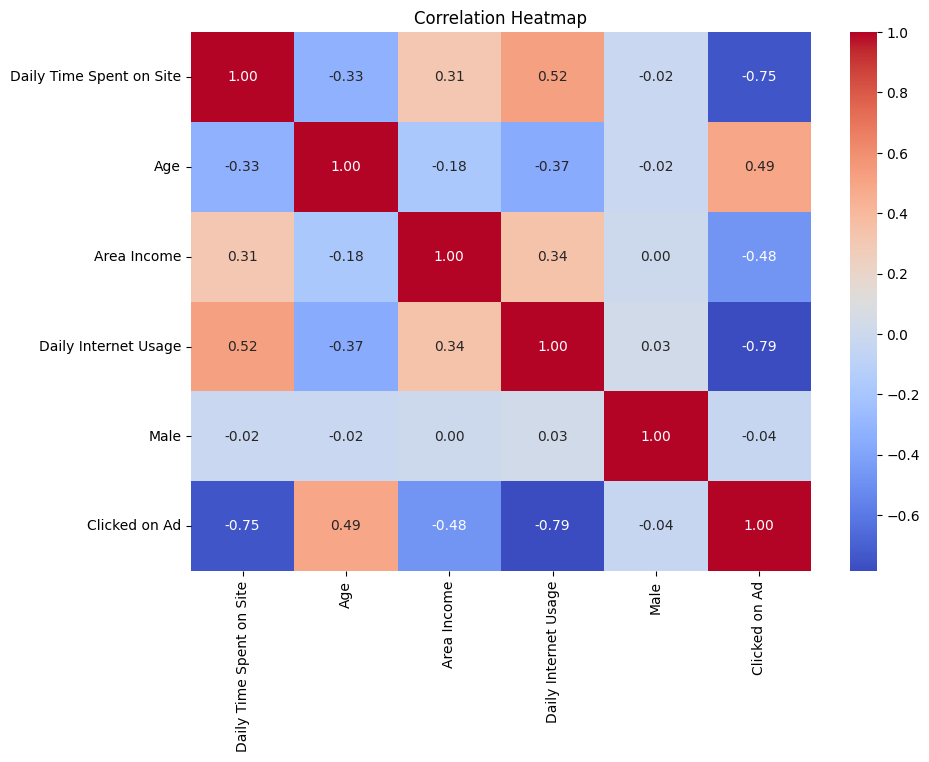


Features:


,Daily Time Spent on Site,Daily Internet Usage
0,68.95,256.09
1,80.23,193.77
2,69.47,236.50
3,74.15,245.89
4,68.37,225.58



Target:


,Clicked on Ad
0,0
1,0
2,0
3,0
4,0



Training Data: (800, 2)
Testing Data: (200, 2)

Model Trained Successfully!

First 10 Predicted Classes:
[1 0 0 0 1 1 1 1 0 0]

First 10 Predicted Probabilities:
[0.99878923 0.0189869  0.00817417 0.07414317 0.98485865 0.99751288
 0.94456674 0.94819075 0.16328692 0.02313479]

Accuracy: 0.96

Confusion Matrix:
[[96  4]
 [ 4 96]]


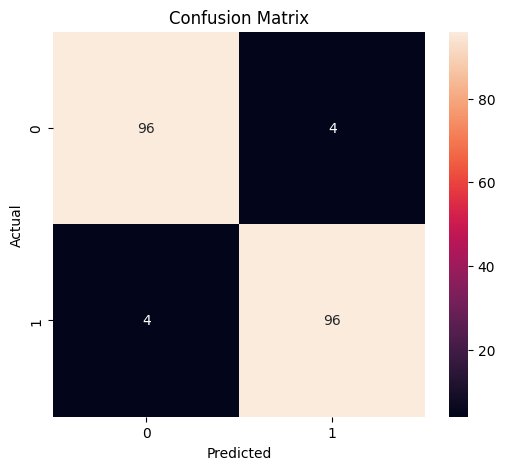


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       100
           1       0.96      0.96      0.96       100

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200

Precision: 0.96

AUC: 0.9869


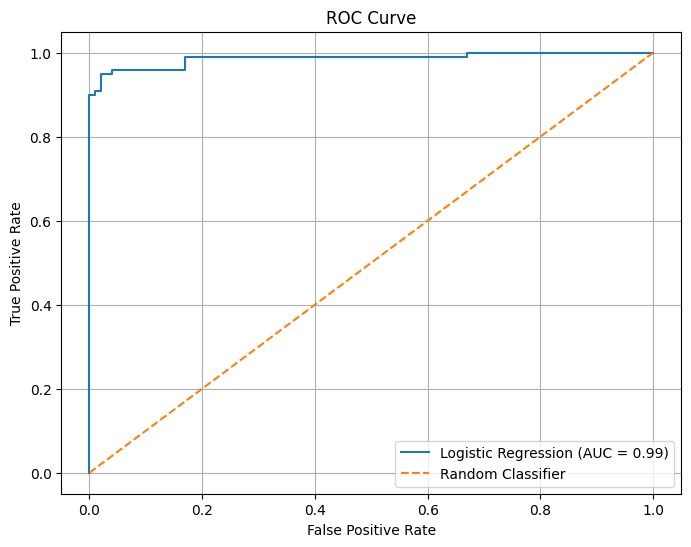

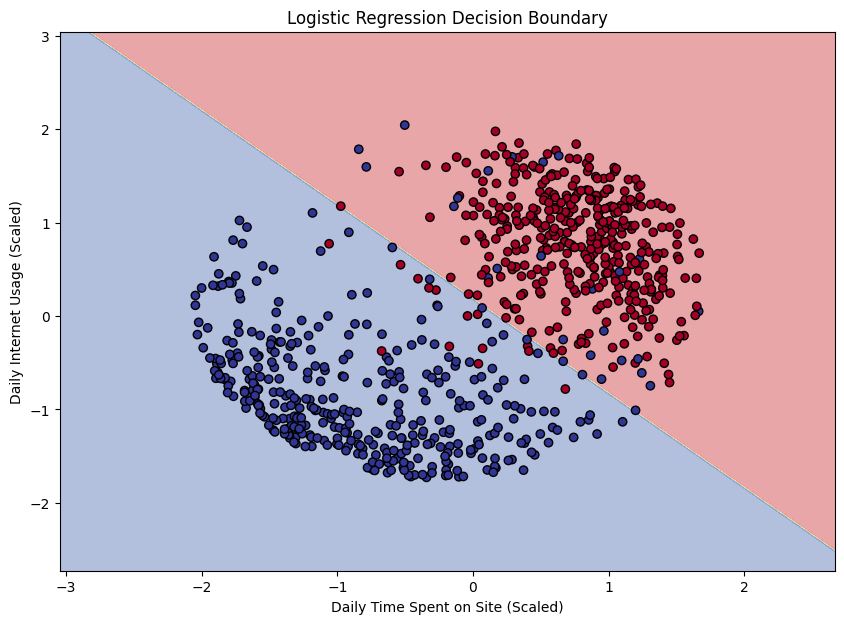

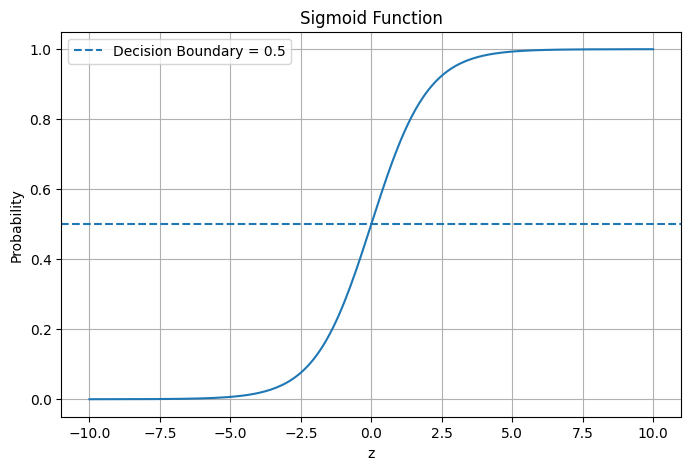


Model Intercept:
[0.43570691]

Model Coefficients:
[[-2.37249185 -2.34037177]]

Feature Coefficients:


,Feature,Coefficient
0,Daily Time Spent on Site,-2.372492
1,Daily Internet Usage,-2.340372



Practical 02 Completed Successfully!


In [1]:
# ============================================================
# PRACTICAL 02: LOGISTIC REGRESSION
# Binary Classification, Sigmoid, Decision Boundary, ROC & AUC
# ============================================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    roc_curve,
    roc_auc_score
)

# ============================================================
# 1. LOAD DATASET
# ============================================================

df = pd.read_csv("/content/advertising.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
display(df.head())

# ============================================================
# 2. DATA INFORMATION
# ============================================================

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

# ============================================================
# 3. TARGET DISTRIBUTION
# ============================================================

print("\nClicked on Ad Distribution:")
print(df["Clicked on Ad"].value_counts())

plt.figure(figsize=(6, 5))
df["Clicked on Ad"].value_counts().plot(kind="bar")
plt.title("Clicked on Ad Distribution")
plt.xlabel("Clicked on Ad")
plt.ylabel("Number of Users")
plt.show()

# ============================================================
# 4. CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(10, 7))

sns.heatmap(
    df.select_dtypes(include=["int64", "float64"]).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

# ============================================================
# 5. FEATURE SELECTION
# ============================================================

X = df[[
    "Daily Time Spent on Site",
    "Daily Internet Usage"
]]

y = df["Clicked on Ad"]

print("\nFeatures:")
display(X.head())

print("\nTarget:")
display(y.head())

# ============================================================
# 6. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)

# ============================================================
# 7. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================================
# 8. TRAIN LOGISTIC REGRESSION MODEL
# ============================================================

model = LogisticRegression()

model.fit(X_train_scaled, y_train)

print("\nModel Trained Successfully!")

# ============================================================
# 9. PREDICTION
# ============================================================

y_pred = model.predict(X_test_scaled)

y_probability = model.predict_proba(X_test_scaled)[:, 1]

print("\nFirst 10 Predicted Classes:")
print(y_pred[:10])

print("\nFirst 10 Predicted Probabilities:")
print(y_probability[:10])

# ============================================================
# 10. ACCURACY
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", round(accuracy, 4))

# ============================================================
# 11. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ============================================================
# 12. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ============================================================
# 13. PRECISION
# ============================================================

precision = precision_score(y_test, y_pred)

print("Precision:", round(precision, 4))

# ============================================================
# 14. ROC CURVE AND AUC
# ============================================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

auc = roc_auc_score(
    y_test,
    y_probability
)

print("\nAUC:", round(auc, 4))

# ============================================================
# 15. ROC CURVE PLOT
# ============================================================

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# 16. DECISION BOUNDARY
# ============================================================

x_min = X_train_scaled[:, 0].min() - 1
x_max = X_train_scaled[:, 0].max() + 1

y_min = X_train_scaled[:, 1].min() - 1
y_max = X_train_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]

Z = model.predict(grid)

Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.4,
    cmap="RdYlBu"
)

plt.scatter(
    X_train_scaled[:, 0],
    X_train_scaled[:, 1],
    c=y_train,
    edgecolor="k",
    cmap="RdYlBu"
)

plt.xlabel("Daily Time Spent on Site (Scaled)")
plt.ylabel("Daily Internet Usage (Scaled)")
plt.title("Logistic Regression Decision Boundary")

plt.show()

# ============================================================
# 17. SIGMOID FUNCTION
# ============================================================

z = np.linspace(-10, 10, 200)

sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(8, 5))

plt.plot(
    z,
    sigmoid
)

plt.axhline(
    0.5,
    linestyle="--",
    label="Decision Boundary = 0.5"
)

plt.xlabel("z")
plt.ylabel("Probability")
plt.title("Sigmoid Function")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# 18. MODEL PARAMETERS
# ============================================================

print("\nModel Intercept:")
print(model.intercept_)

print("\nModel Coefficients:")
print(model.coef_)

print("\nFeature Coefficients:")

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

display(coefficients)

# ============================================================
# END OF PRACTICAL 02
# ============================================================

print("\nPractical 02 Completed Successfully!")